# 📘 Clustering Jerárquico (Agglomerative Clustering)
# 🌳 Dendrograma

Un **dendrograma** es una representación gráfica del proceso jerárquico:

- El eje vertical representa la distancia de fusión.
- Cada unión muestra cuándo dos clusters se combinaron.
- Cortar el árbol a cierta altura define el número de clusters.

Esto permite:
- Explorar la estructura natural de los datos.
- Elegir el número de clusters visualmente.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage

In [3]:
iris = sns.load_dataset("iris")
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [7]:
X = iris.drop(columns=["species"])

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
model = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"   # ward minimiza varianza interna
)

In [10]:
labels = model.fit_predict(X_scaled)

In [11]:
iris["cluster"] = labels
iris

,sepal_length,sepal_width,petal_length,petal_width,species,cluster
0,5.1,3.5,1.4,0.2,setosa,1
1,4.9,3.0,1.4,0.2,setosa,1
2,4.7,3.2,1.3,0.2,setosa,1
3,4.6,3.1,1.5,0.2,setosa,1
4,5.0,3.6,1.4,0.2,setosa,1
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica,0
146,6.3,2.5,5.0,1.9,virginica,0
147,6.5,3.0,5.2,2.0,virginica,0
148,6.2,3.4,5.4,2.3,virginica,0


In [12]:
sil = silhouette_score(X_scaled, labels)
print("Silhouette Score:", round(sil, 3))

Silhouette Score: 0.447


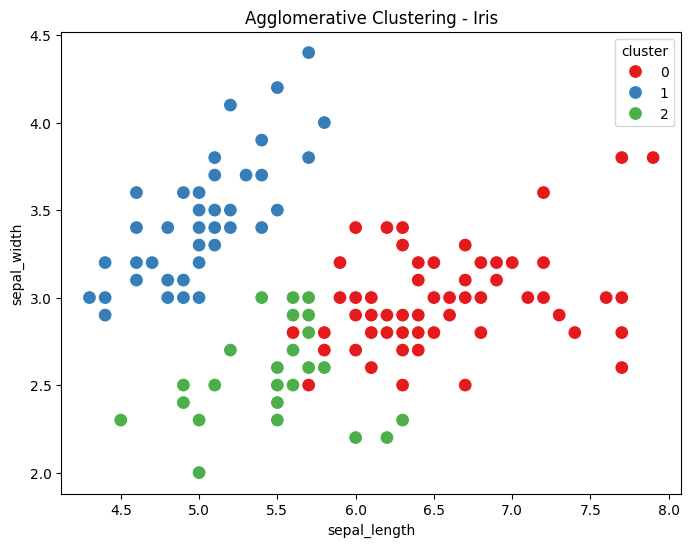

In [13]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=iris,
    x="sepal_length",
    y="sepal_width",
    hue="cluster",
    palette="Set1",
    s=100
)

plt.title("Agglomerative Clustering - Iris")
plt.show()

# Dendrograma

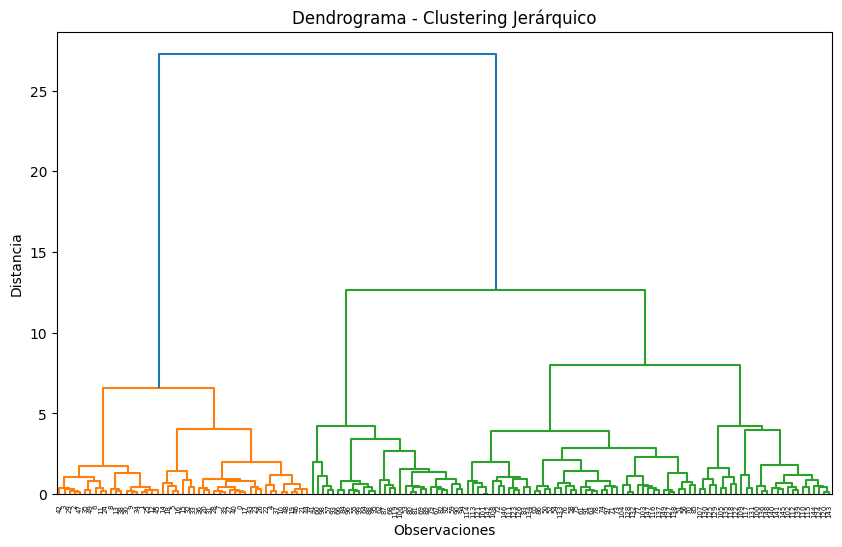

In [14]:
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10,6))
dendrogram(linked)
plt.title("Dendrograma - Clustering Jerárquico")
plt.xlabel("Observaciones")
plt.ylabel("Distancia")
plt.show()

# Comparación con especies reales

In [15]:
print(pd.crosstab(iris["species"], iris["cluster"]))

cluster      0   1   2
species               
setosa       0  49   1
versicolor  23   0  27
virginica   48   0   2


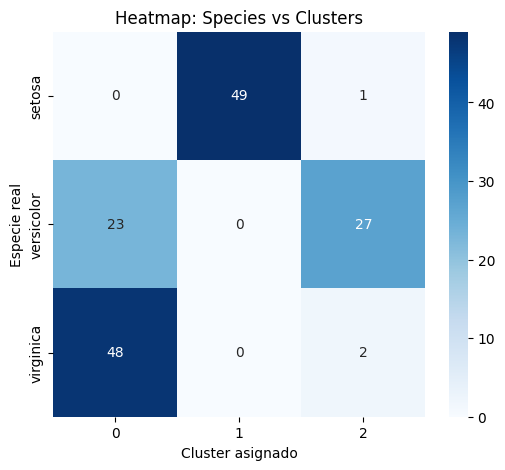

In [16]:
# ======================================================
# 🔹 Heatmap de clusters vs especies reales
# ======================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Tabla de contingencia
ct = pd.crosstab(iris["species"], iris["cluster"])

plt.figure(figsize=(6,5))
sns.heatmap(ct,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.title("Heatmap: Species vs Clusters")
plt.xlabel("Cluster asignado")
plt.ylabel("Especie real")
plt.show()
